<a href="https://colab.research.google.com/github/Lyanan85/In-GameSeries/blob/venv/INTEGRANDO_PANDAS_SQLITE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Integrando sqlite e pandas
#### material de estudo
-insigths basicos
-conceitos
-gráficos

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

## A variavel conn recebe o comando que conecta com o bancio de dados

### a variavel cursor recebe  o cursor, que é utilizado para navegar no banco de dados

In [ ]:
conn=sqlite3.connect('Material_de_estudo.db')
cursor=conn.cursor()


## Verificando a tabela principal com os dados

In [ ]:

tabelaprincipal=pd.read_sql_query("""SELECT* FROM Material_de_estudo""", conn)
tabelaprincipal

,Year,StateAbbr,StateDesc,CityName,GeographicLevel,DataSource,Category,UniqueID,Measure,Data_Value_Unit,...,High_Confidence_Limit,Data_Value_Footnote_Symbol,Data_Value_Footnote,PopulationCount,Geolocation,CategoryID,MeasureId,CityFIPS,TractFIPS,Short_Question_Text
0,2015,IN,Indiana,Fishers,City,BRFSS,Health Outcomes,1823278,High blood pressure among adults aged >=18 Years,%,...,24.7,,,76794,POINT (-85.969310702 39.9587635263),HLTHOUT,BPHIGH,1823278.0,NaN,High Blood Pressure
1,2015,CA,California,Milpitas,City,BRFSS,Health Outcomes,0647766,High blood pressure among adults aged >=18 Years,%,...,22.5,,,66790,POINT (-121.892083025 37.433869763),HLTHOUT,BPHIGH,647766.0,NaN,High Blood Pressure
2,2015,CT,Connecticut,Stamford,City,BRFSS,Health Outcomes,0973000,High blood pressure among adults aged >=18 Years,%,...,26.2,,,122643,POINT (-73.5589363142 41.1049145013),HLTHOUT,BPHIGH,973000.0,NaN,High Blood Pressure
3,2015,CA,California,Elk Grove,City,BRFSS,Health Outcomes,0622020,High blood pressure among adults aged >=18 Years,%,...,27.8,,,153015,POINT (-121.384137762 38.4159992006),HLTHOUT,BPHIGH,622020.0,NaN,High Blood Pressure
4,2015,FL,Florida,Palm Bay,City,BRFSS,Prevention,1254000,Cholesterol screening among adults aged >=18 Y...,%,...,78.4,,,103190,POINT (-80.6666722846 27.9838255249),PREVENT,CHOLSCREEN,1254000.0,NaN,Cholesterol Screening
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
810098,2016,CA,California,Clovis,Census Tract,BRFSS,Unhealthy Behaviors,0614218-06019005911,Binge drinking among adults aged >=18 Years,%,...,19.0,,,3346,POINT (-119.650325584 36.7945965568),UNHBEH,BINGE,614218.0,6.019006e+09,Binge Drinking
810099,2016,CA,California,Fremont,Census Tract,BRFSS,Unhealthy Behaviors,0626000-06001442400,Current smoking among adults aged >=18 Years,%,...,14.3,,,6253,POINT (-121.973779294 37.5313807021),UNHBEH,CSMOKING,626000.0,6.001442e+09,Current Smoking
810100,2016,HI,Hawaii,Honolulu,Census Tract,BRFSS,Health Outcomes,15003009400,Coronary heart disease among adults aged >=18 ...,%,...,7.1,,,5155,POINT (-158.038203503 21.4942478343),HLTHOUT,CHD,15003.0,1.500301e+10,Coronary Heart Disease
810101,2016,CA,California,Los Angeles,Census Tract,BRFSS,Health Outcomes,0644000-06037211410,Mental health not good for >=14 days among adu...,%,...,12.0,,,3095,POINT (-118.307315461 34.0726142562),HLTHOUT,MHLTH,644000.0,6.037211e+09,Mental Health


## Utilizamos o meto sql_query para realizar uma consulta no banco de dados
### finalizamos a consulta com o conn


##### pesquisando quantos e quais anos essa pesquisa se refere

## Contando a quantidade de pesquisar por ano
o select year seleciona a coluna ano, COUNT(*) Conta a tabela inteira, após receber um apelido é usado a cláusula where in pra filtra dois resultados, depois o resultado é agrupado com a cláusula group by

In [ ]:
contagem_casos=pd.read_sql_query("SELECT Year, COUNT(*) AS Contagem_Entrevistados FROM Material_de_estudo where Year in (2015,2016) GROUP BY Year", conn)
contagem_casos

,Year,Contagem_Entrevistados
0,2015,116024
1,2016,694079


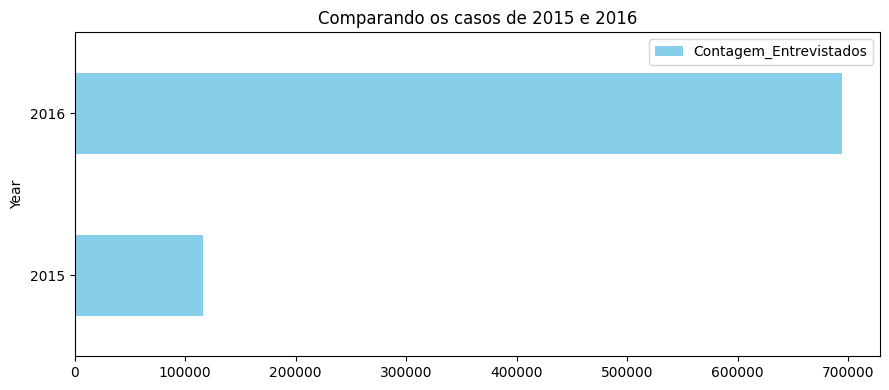

In [ ]:
Gráfico_casos_ano=contagem_casos
contagem_casos.set_index('Year', inplace=True)
Gráfico_casos_ano.plot(kind="barh", color="Skyblue",figsize=(9,4))
plt.title("Comparando os casos de 2015 e 2016")
plt.tight_layout()
plt.show()

## Conferindo de forma decrescente os Estados referentes a esta pesquisa

In [ ]:
#GROUP BY StateDesc: Agrupa os dados por cada valor único da coluna "StateDesc". Isso permite contar as ocorrências de cada estado.

contagem_estados=pd.read_sql_query("SELECT StateDesc, COUNT(*) as Contagem_estados_por_casos FROM Material_de_estudo GROUP BY StateDesc ORDER BY    Contagem_estados_por_casos DESC",conn)
contagem_estados

,StateDesc,Contagem_estados_por_casos
0,California,156778
1,Texas,89422
2,New York,70133
3,Florida,39025
4,Illinois,37458
5,Arizona,29678
6,Ohio,24111
7,North Carolin,23305
8,Michigan,21672
9,Colorado,20549


## Agrupando os 20 Estados mais relevantes para esta pesquisa usando a cláusula limit

In [ ]:
Estados_mais_relevantes=pd.read_sql_query("SELECT StateDesc, COUNT(*) as Contagem_estados_por_casos FROM Material_de_estudo GROUP BY StateDesc ORDER BY    Contagem_estados_por_casos DESC limit 20",conn)
Estados_mais_relevantes

,StateDesc,Contagem_estados_por_casos
0,California,156778
1,Texas,89422
2,New York,70133
3,Florida,39025
4,Illinois,37458
5,Arizona,29678
6,Ohio,24111
7,North Carolin,23305
8,Michigan,21672
9,Colorado,20549


## Criando um gráfico para os 20 estados mais relevantes para esta pesquisa
#### o metodo set_index define o index(0,1,2) nos estados na coluna State desc da consulta cima
e o método implace=True faz com que os dados sejam, sobescritos na propia planilha

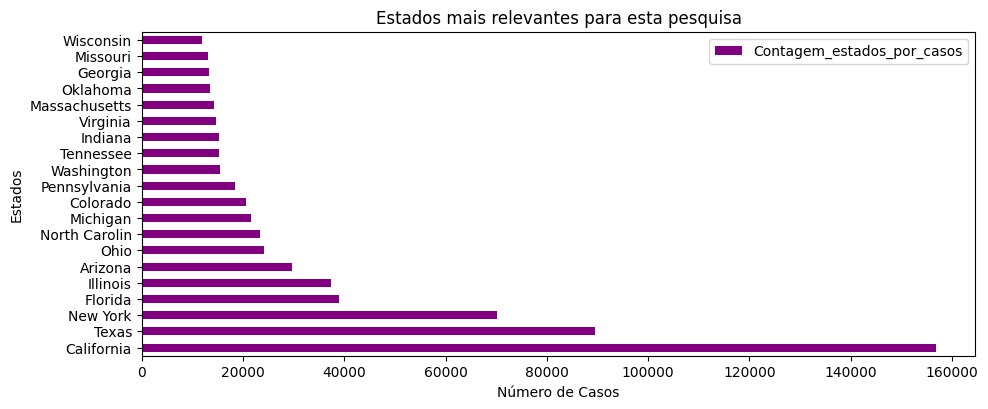

In [ ]:
Estados_mais_relevantes.set_index('StateDesc', inplace=True)
Grafico_relevancia=Estados_mais_relevantes.plot(kind='barh', color='purple', figsize=(10,4))
plt.title("Estados mais relevantes para esta pesquisa")
plt.tight_layout()
plt.xlabel("Número de Casos")
plt.ylabel("Estados")
plt.show()

## Descobrindo os casos mais frequentes nessa pesquisa

In [ ]:
casos_frequentes=pd.read_sql_query("SELECT Measure, count(*) as contagem_casos_frequentes FROM Material_de_estudo GROUP BY Measure ORDER BY contagem_casos_frequentes DESC", conn)
casos_frequentes

,Measure,contagem_casos_frequentes
0,Visits to doctor for routine checkup within th...,29006
1,Visits to dentist or dental clinic among adult...,29006
2,Taking medicine for high blood pressure contro...,29006
3,Stroke among adults aged >=18 Years,29006
4,Sleeping less than 7 hours among adults aged >...,29006
5,Physical health not good for >=14 days among a...,29006
6,Obesity among adults aged >=18 Years,29006
7,No leisure-time physical activity among adults...,29006
8,Mental health not good for >=14 days among adu...,29006
9,High cholesterol among adults aged >=18 Years ...,29006


## comparar as tendências temporais da taxa de pressão alta e triagem de colesterol ao longo dos anos.
"High blood pressure among adults aged >=18 Years " e "Cholesterol screening among adults aged >=18 Years  na pesquisa

In [ ]:
filtro=pd.read_sql_query("SELECT * FROM Material_de_estudo where Measure='High blood pressure among adults aged >=18 Years' and 'Cholesterol screening among adults aged >=18 Years'", conn)
filtro

,Year,StateAbbr,StateDesc,CityName,GeographicLevel,DataSource,Category,UniqueID,Measure,Data_Value_Unit,...,High_Confidence_Limit,Data_Value_Footnote_Symbol,Data_Value_Footnote,PopulationCount,Geolocation,CategoryID,MeasureId,CityFIPS,TractFIPS,Short_Question_Text


## Como podemos verificar, a tabela esta vazia, isso se da pelos motivos de que existem espaços vazios nessa pesquisa, assim sendo necessario um pequeno tratamento de dados

essa linha de codigo mostra para nós que existem espaços vazios

In [ ]:
unique_measures = pd.read_sql_query("SELECT DISTINCT Measure FROM Material_de_estudo", conn)
print(unique_measures)


                                              Measure
0    High blood pressure among adults aged >=18 Years
1   Cholesterol screening among adults aged >=18 Y...
2              Arthritis among adults aged >=18 Years
3                 Stroke among adults aged >=18 Years
4                Obesity among adults aged >=18 Years
5        Mammography use among women aged 50–74 Years
6         All teeth lost among adults aged >=65 Years
7     Diagnosed diabetes among adults aged >=18 Years
8         Binge drinking among adults aged >=18 Years
9   Cancer (excluding skin cancer) among adults ag...
10  Mental health not good for >=14 days among adu...
11  Chronic obstructive pulmonary disease among ad...
12       Current smoking among adults aged >=18 Years
13  Coronary heart disease among adults aged >=18 ...
14  Papanicolaou smear use among adult women aged ...
15        Current asthma among adults aged >=18 Years
16  Sleeping less than 7 hours among adults aged >...
17  Visits to dentist or den

## Tratamento de dados simples
#### A cláusula trim remove espaços vazios, metodo banco de dados sqlite
#### Se fosse um arquivo csv se usario o metodo str.strip do pandas


## o trim remove os espaços em branco na coluna measure
## CASE WHEN: É como dizer "Se o caso for que...".

 ##### o then da o valor de 1 para cada valor especificado no filtro, e o comando case when termina com a cláusula end
 ##### após a filtragem o SUM conta todos os valores que receberam 1  
 #####



In [ ]:
filtro2015_2016 = pd.read_sql_query("""
    SELECT Year,
           SUM(CASE WHEN TRIM(Measure) = 'High blood pressure among adults aged >=18 Years' THEN 1 ELSE 0 END) AS Contagem_Pressao_Alta,
           SUM(CASE WHEN TRIM(Measure) = 'Cholesterol screening among adults aged >=18 Years' THEN 1 ELSE 0 END) AS Contagem_Colesterol_Alto
    FROM Material_de_estudo
    WHERE TRIM(Measure) IN ('High blood pressure among adults aged >=18 Years', 'Cholesterol screening among adults aged >=18 Years')
    AND Year IN ('2015', '2016')  -- Filtra apenas os anos 2015 e 2016
    GROUP BY Year
""", conn)
filtro2015_2016

,Year,Contagem_Pressao_Alta,Contagem_Colesterol_Alto
0,2015,29006,29006


## como podemos ver não temos dados filtrados nesta pesquisa para o ano de  2016, somente para o ano de 2015

## Descobrindo Quantos casos de colesterol e pressão alta tivemos nessa pesquisa no ano de 2015

In [ ]:
DADOS2015 = pd.read_sql_query("""
    SELECT
        Year AS Ano,
        Measure AS Medida,
        AVG(Data_Value) AS Data_Value
    FROM Material_de_Estudo
    WHERE TRIM(Measure) in ('High blood pressure among adults aged >=18 Years', 'Cholesterol screening among adults aged >=18 Years') and Year=2015
    GROUP BY Year, Measure
""", conn)
DADOS2015

,Ano,Medida,Data_Value
0,2015,Cholesterol screening among adults aged >=18 Y...,72.657522
1,2015,High blood pressure among adults aged >=18 Years,30.491621


## Criando gráfico para representar os Casos de Pressão alta e Colesterol alto

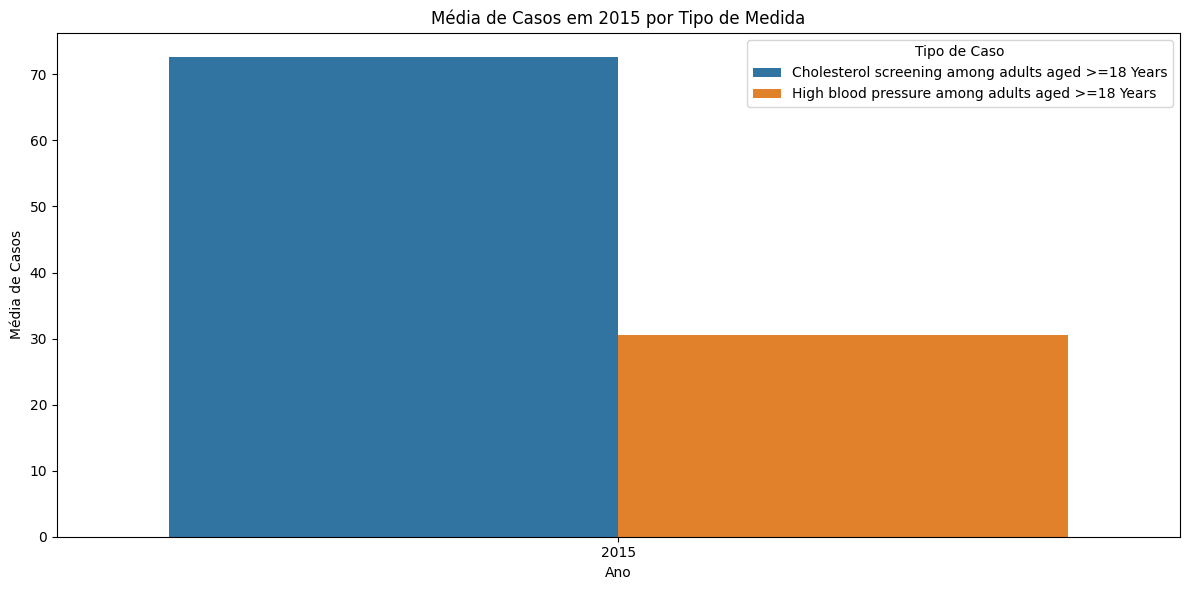

In [ ]:



plt.figure(figsize=(12, 6))
sns.barplot(data=DADOS2015, x="Ano", y="Data_Value", hue="Medida")
plt.title("Média de Casos em 2015 por Tipo de Medida")  # Adicionando um título
plt.legend(title='Tipo de Caso')  # Corrigido para 'title' com t minúsculo
plt.tight_layout()
plt.xlabel("Ano")
plt.ylabel("Média de Casos")
plt.show()


## Descobrindo a média de frequencia de TODOS os casos

In [ ]:
DADOS2015 = pd.read_sql_query("""
    SELECT
        Year AS Ano,
        Measure AS Medida,
        AVG(Data_Value) AS Data_Value
    FROM Material_de_Estudo

    GROUP BY Year, Measure ORDER BY Data_Value DESC
""", conn)
DADOS2015

,Ano,Medida,Data_Value
0,2016,Papanicolaou smear use among adult women aged ...,82.999305
1,2016,Mammography use among women aged 50–74 Years,79.100245
2,2015,Cholesterol screening among adults aged >=18 Y...,72.657522
3,2015,Taking medicine for high blood pressure contro...,71.966826
4,2016,Visits to doctor for routine checkup within th...,69.384538
5,2016,"Fecal occult blood test, sigmoidoscopy, or col...",61.861370
6,2016,Visits to dentist or dental clinic among adult...,61.303903
7,2016,Sleeping less than 7 hours among adults aged >...,36.673082
8,2015,High cholesterol among adults aged >=18 Years ...,34.530764
9,2016,Older adult men aged >=65 Years who are up to ...,31.744107


## Descobrindo a media de casos de colesterol e pressão alte entre o estados americanos

In [ ]:
estadosfrequentes=pd.read_sql_query("""
        SELECT
            StateDesc AS DescricaoEstado,
            Measure AS Medida,
            AVG(Data_Value) AS Datas_Value
        FROM Material_de_estudo
        WHERE TRIM(Measure) IN ('High blood pressure among adults aged >=18 Years', 'Cholesterol screening among adults aged >=18 Years') AND Year=2015
        GROUP BY StateDesc, Measure
        ORDER BY Datas_Value DESC""", conn)
estadosfrequentes

,DescricaoEstado,Medida,Datas_Value
0,West Virginia,Cholesterol screening among adults aged >=18 Y...,80.575000
1,District of C,Cholesterol screening among adults aged >=18 Y...,77.517778
2,Virginia,Cholesterol screening among adults aged >=18 Y...,76.357774
3,North Carolin,Cholesterol screening among adults aged >=18 Y...,76.143308
4,United States,Cholesterol screening among adults aged >=18 Y...,76.100000
...,...,...,...
99,North Dakota,High blood pressure among adults aged >=18 Years,24.888889
100,Minnesota,High blood pressure among adults aged >=18 Years,24.416358
101,Colorado,High blood pressure among adults aged >=18 Years,24.364185
102,Utah,High blood pressure among adults aged >=18 Years,22.767729


## usando o metodo pivot table
### ele ciora uma tabelça dinamica, onde voce atribui as seguintes informações (index, columns  e values) a sua tabela criada

In [ ]:
tabela_pivot = estadosfrequentes.pivot_table(
    index='DescricaoEstado',
    columns='Medida',
    values='Datas_Value')
display(tabela_pivot)

Medida,Cholesterol screening among adults aged >=18 Years,High blood pressure among adults aged >=18 Years
DescricaoEstado,,
Alabama,75.808683,40.003922
Alaska,68.815789,27.101754
Arizona,73.059961,27.579199
Arkansas,71.525000,35.117969
California,73.074238,26.870608
Colorado,72.616433,24.364185
Connecticut,73.125847,30.847034
Delaware,72.238462,37.488462
District of C,77.517778,30.148889


In [ ]:
tabela_pivot = estadosfrequentes.pivot_table(
    index='DescricaoEstado',
    columns='Medida',
    values='Datas_Value')
display(tabela_pivot)

Medida,Cholesterol screening among adults aged >=18 Years,High blood pressure among adults aged >=18 Years
DescricaoEstado,,
Alabama,75.808683,40.003922
Alaska,68.815789,27.101754
Arizona,73.059961,27.579199
Arkansas,71.525000,35.117969
California,73.074238,26.870608
Colorado,72.616433,24.364185
Connecticut,73.125847,30.847034
Delaware,72.238462,37.488462
District of C,77.517778,30.148889


## Grafico para representar o estados com a maior taxa de pressão alta e triagem de colesterol

<Figure size 800x1000 with 0 Axes>

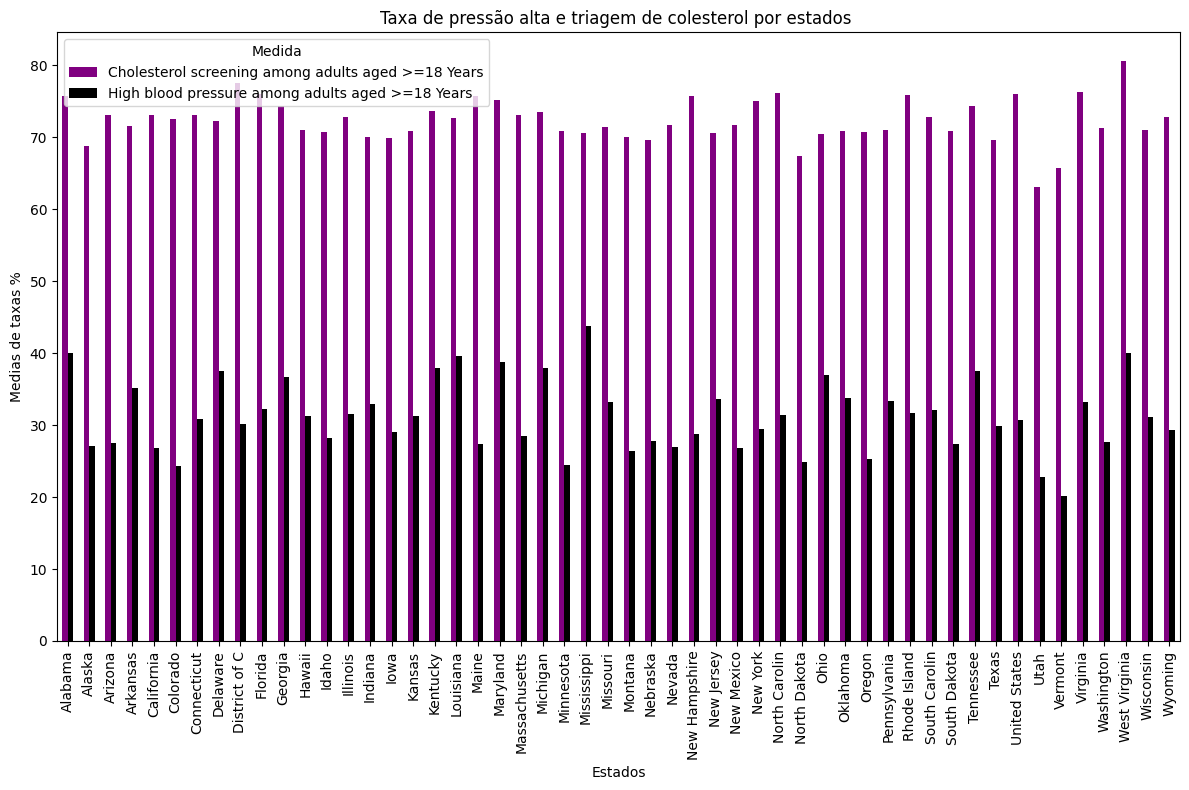

In [ ]:
plt.figure(figsize=(8,10))
GraficoPorEstado=tabela_pivot.plot(kind='bar', color=["Purple", "Black"],figsize=(12,8))
plt.title("Taxa de pressão alta e triagem de colesterol por estados ")
plt.xlabel("Estados")
plt.ylabel("Medias de taxas %")
plt.xticks(rotation=450)
plt.legend(title="Medida")
plt.tight_layout()
plt.show()


## Gráfico de mapa de calor
 annot=True' exibe os valores dentro das células.
 'cmap="coolwarm"' usa uma paleta de cores que vai do azul ao vermelho.
 'linewidths=.5' define a espessura das linhas de separação entre as células.

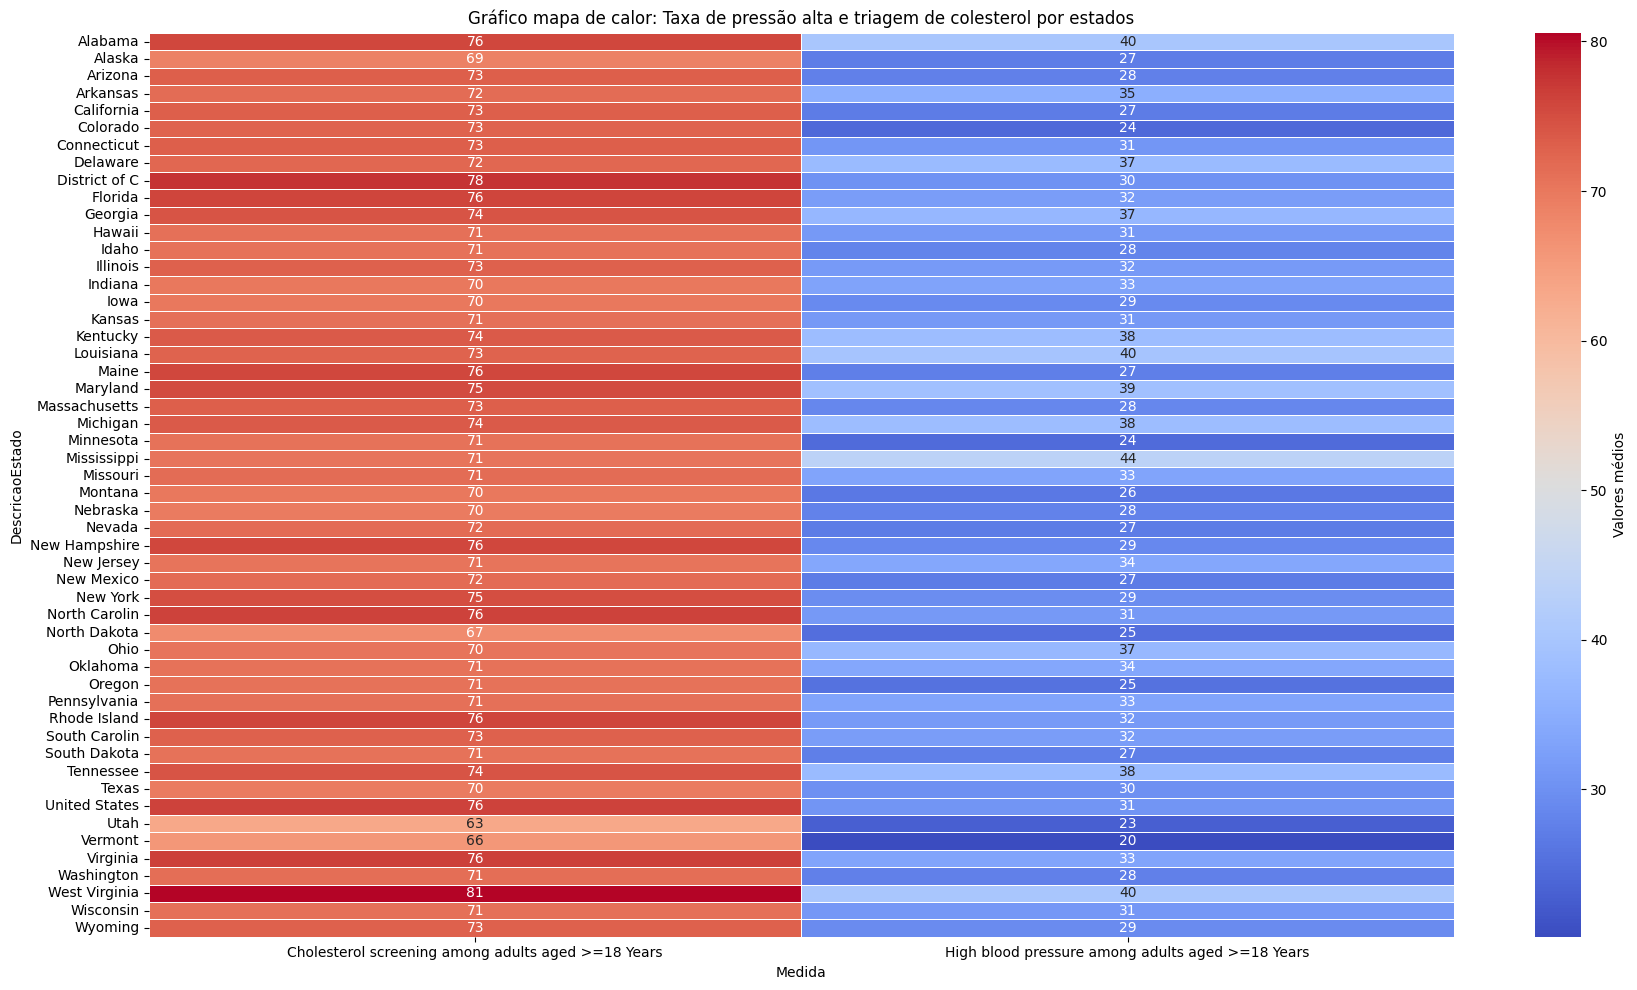

In [ ]:
plt.figure(figsize=(18,10))
sns.heatmap(tabela_pivot, annot=True, cmap="coolwarm", linewidths=.5, cbar_kws={'label':'Valores médios'})
plt.title("Gráfico mapa de calor: Taxa de pressão alta e triagem de colesterol por estados")
plt.xticks(rotation=360)
plt.tight_layout()
plt.show()

# Correlação entre pressão alta e triagem de colesterol
## O gráfico de correlação, ou a matriz de correlação, é uma ferramenta que mede o grau de relação linear entre duas variáveis. Os valores dessa correlação variam entre -1 e 1:
### O comando .corr() é uma função do pandas usada para calcular a correlação entre as colunas de um DataFrame.
Quando usamos esse comando, ele nos dá uma matriz de correlação, que mostra o quão relacionadas estão as variáveis numéricas entre si.

Correlação entre os casos de pressão alta e colesterol alto
Medida                                              Cholesterol screening among adults aged >=18 Years  \
Medida                                                                                                   
Cholesterol screening among adults aged >=18 Years                                           1.000000    
High blood pressure among adults aged >=18 Years                                             0.455418    

Medida                                              High blood pressure among adults aged >=18 Years  
Medida                                                                                                
Cholesterol screening among adults aged >=18 Years                                          0.455418  
High blood pressure among adults aged >=18 Years                                            1.000000  


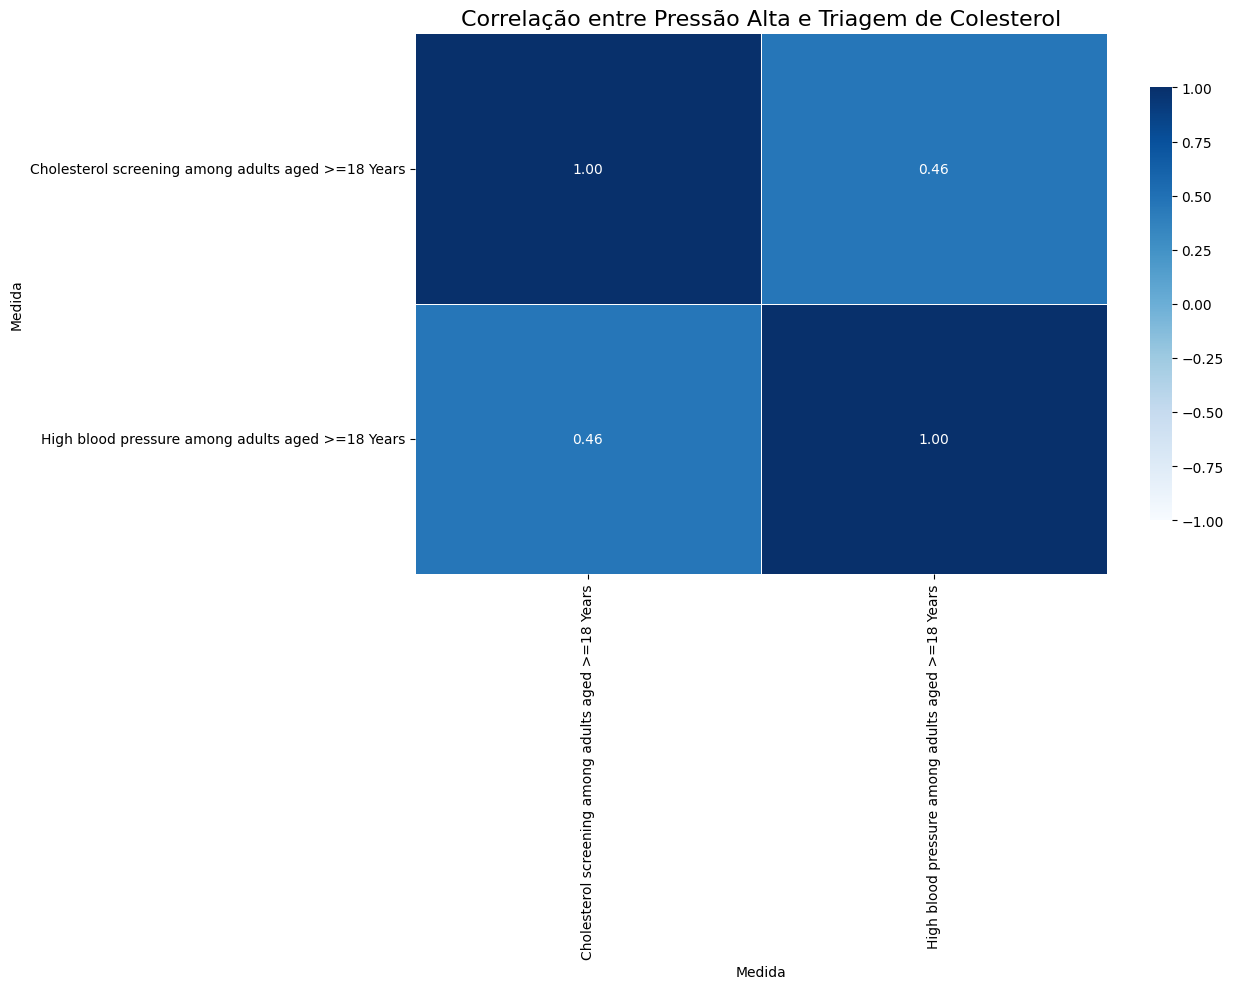

In [ ]:
# Calcula a correlação entre os casos de pressão alta e colesterol alto
correlacao = tabela_pivot.corr()

# Exibe a correlação
print("Correlação entre os casos de pressão alta e colesterol alto")
print(correlacao)


In [ ]:

# Cria o heatmap da correlação
plt.figure(figsize=(13, 10))
sns.heatmap(correlacao, annot=True, cmap="Blues", linewidths=0.5, fmt=".2f", vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
plt.title("Correlação entre Pressão Alta e Triagem de Colesterol", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## como podemos ver, existe uma correlação entre os dados, mas é uma correlação fraca